# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/girishpatil935/ML_Internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

# Structured Content Performance Archetypes: A Data-Driven Action Playbook

## Abstract

This research asks what measurable performance archetypes exist across a large content inventory and how those patterns can support content-review decisions. Using the FlyRank internship warehouse, the analysis aggregates March 2026 Google Search Console measurements at the client-content level and represents each page using impressions, clicks, CTR, average position, and position volatility. A transparent CTR opportunity baseline is compared with an unsupervised K-Means clustering approach, with client-grouped validation and explicit leakage checks used to assess whether the observed structure is stable and whether the evaluation is honest. The analysis produced three descriptive performance clusters and a ranked review queue of 1,368 pages with positive baseline opportunity scores, with high-visibility, lower-CTR pages receiving the highest review priority. The resulting playbook is intended as decision support for human review rather than as an automated system for rewriting, pruning, merging, or predicting future search performance.

### Research question

**What performance archetypes exist across the content inventory, and how can those observed patterns support content-review prioritization?**

The analysis focuses on measurable search-performance patterns rather than semantic content categories because the available warehouse does not contain article text.

### Decision supported

The analysis is designed to help a content or SEO team decide:

- Which pages deserve review first?
- What observed performance pattern should a reviewer investigate?
- Which pages show measurable visibility but a potential CTR opportunity?
- Which pages require deeper investigation before any content action is considered?

The output is therefore a **review-prioritization framework**, not an automated content decision system.

### Scope

The research uses March 2026 as the fixed development window for the page-level feature vector. The analysis combines:

1. A transparent CTR-based baseline for ranking review opportunities.
2. K-Means clustering to provide descriptive performance archetype context.
3. Client-grouped validation to test the stability of the clustering structure across unseen clients.
4. A human-reviewed action playbook that maps observed patterns to investigation priorities.

The central question is descriptive and operational: **what patterns are present in the observed data, and how can they be used responsibly to organize human review?**

In [ ]:
research_question = {
    "question": (
        "What performance archetypes exist across the content inventory, "
        "and how can those observed patterns support content-review prioritization?"
    ),
    "development_window": "March 2026",
    "unit_of_analysis": "client-content pair",
    "baseline": "CTR opportunity by search-position tier",
    "model": "K-Means clustering",
    "decision_output": "human-reviewed content action prioritization"
}

for key, value in research_question.items():
    print(f"{key}: {value}")

question: What performance archetypes exist across the content inventory, and how can those observed patterns support content-review prioritization?
development_window: March 2026
unit_of_analysis: client-content pair
baseline: CTR opportunity by search-position tier
model: K-Means clustering
decision_output: human-reviewed content action prioritization


### Dataset and scope

This research uses the **FlyRank ML Internship warehouse**, accessed through the `FlyRank/internship-warehouse` dataset. The warehouse contains daily content-performance observations covering approximately 79 million rows, with pseudonymized client and content identifiers.

The primary analytical table is the daily content-performance fact table:

`fact_content_daily_performance`

Its analytical grain is:

**report_date × client_hash_id × content_hash_id**

The available measurements include Google Search Console performance, Google Analytics measurements, traffic-source sessions, AI-referral measurements, and engagement signals.

### Time windows

The warehouse covers daily observations from **January 27, 2025 through June 30, 2026**.

Different windows were used for different purposes:

- **March 2026** — fixed development window used to construct the client-content feature vector and develop the clustering analysis.
- **April 2026** — used only for the Week-5 leakage check and excluded from the final feature vector.
- **June 2026** — treated as a later final month and kept sealed from model development.
- Earlier historical observations were used for contextual understanding where appropriate, but the final clustering features were constructed from March 2026 only.

The March window was chosen as a fixed development period so that feature construction, baseline scoring, clustering, and validation could be evaluated consistently without using later observations.

### Data availability

Google Search Console coverage is uneven across the warehouse. Some client-content observations have GSC measurements while others do not.

For the clustering analysis, only observations where `gsc_data_available` was true were used to construct the search-performance feature vector.

This means the analysis describes the portion of the content inventory with available GSC measurements rather than the entire warehouse population.

### Features used

The final clustering feature vector contains five March 2026 measurements:

- **Impressions** — total observed Google Search impressions.
- **Clicks** — total observed Google Search clicks.
- **CTR** — clicks divided by impressions.
- **Average position** — average observed search position, excluding zero-valued no-data observations.
- **Position volatility** — sample standard deviation of observed daily search position.

Impressions and clicks were log-transformed before clustering because their distributions were highly right-skewed. Missing feature values were median-imputed and the resulting features were standardized.

### What was excluded

The following information was excluded from the model features:

- `client_hash_id` and `content_hash_id` as numeric predictors, because they are identifiers rather than performance measurements.
- Report dates and month fields, because the development window was fixed.
- Future observations such as April 2026 measurements, to prevent temporal leakage.
- Trend-derived labels or fields, because they are derived from performance outcomes.
- Baseline action scores, because they are downstream decision outputs rather than independent features.
- GSC availability flags, because availability describes data coverage rather than page performance.
- Google Analytics, traffic-source, AI-referral, and engagement fields, because the selected clustering task focuses specifically on observed search-performance patterns.

### Public-safety framing

The analysis uses pseudonymized identifiers only for grouping, joining, validation, and traceability. Client names, URLs, private search queries, and other identifying information are not included in the research paper or public artifacts.

The reported findings are aggregate or pseudonymized and are intended to describe measured performance patterns rather than individual clients or private properties.

In [ ]:
import os
import getpass
import duckdb
import pandas as pd

def get_hf_token():
    token = os.environ.get("HF_TOKEN")

    if token:
        return token

    try:
        from google.colab import userdata
        token = userdata.get("HF_TOKEN")

        if token:
            return token
    except Exception:
        pass

    return getpass.getpass(
        "Paste your Hugging Face READ token (hf_...): "
    )

HF_TOKEN = get_hf_token()

con = duckdb.connect()

con.execute(f"""
CREATE OR REPLACE SECRET hf
(
    TYPE huggingface,
    TOKEN '{HF_TOKEN}'
)
""")

REL = "hf://datasets/FlyRank/internship-warehouse"

FACT_DAILY = (
    f"read_parquet("
    f"'{REL}/fact_content_daily_performance/**/*.parquet'"
    f")"
)

print("DuckDB connection ready.")
print("Warehouse relation ready.")

DuckDB connection ready.
Warehouse relation ready.


In [ ]:
# Verify the warehouse scope used in the paper

import duckdb
import pandas as pd

# Reuse the existing DuckDB connection if available.
# If the capstone notebook has not created one yet, run the
# warehouse setup cell from the earlier notebooks first.

try:
    con
except NameError:
    raise RuntimeError(
        "DuckDB connection `con` is not defined. "
        "Run the warehouse setup cell before this section."
    )

REL = "hf://datasets/FlyRank/internship-warehouse"

FACT_DAILY = (
    f"read_parquet("
    f"'{REL}/fact_content_daily_performance/**/*.parquet'"
    f")"
)

data_summary = con.sql(f"""
    SELECT
        COUNT(*) AS total_rows,
        MIN(report_date) AS first_date,
        MAX(report_date) AS last_date,
        COUNT(DISTINCT client_hash_id) AS clients,
        COUNT(DISTINCT content_hash_id) AS content_items
    FROM {FACT_DAILY}
""").df()

display(data_summary)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,total_rows,first_date,last_date,clients,content_items
0,78835655,2025-01-27,2026-06-30,70,427292


### Method overview

The analysis follows a two-part approach: a transparent rule-based baseline provides a review-priority score, while K-Means clustering provides descriptive performance archetypes.

The workflow is:

1. Aggregate March 2026 GSC observations to the client-content level.
2. Construct five search-performance features.
3. Apply transformations, imputation, and standardization.
4. Establish a transparent CTR-opportunity baseline.
5. Fit K-Means models across candidate cluster counts.
6. Select the final cluster count using silhouette, cluster size, stability, and interpretability.
7. Validate the clustering structure using a client-grouped holdout.
8. Audit for temporal, identifier, label, and preprocessing leakage.
9. Combine the baseline priority score with cluster context in the final action playbook.

### Feature construction

Each client-content pair is represented using five March 2026 search-performance measurements:

| Feature | Definition |
|---|---|
| Impressions | Sum of observed GSC impressions during March |
| Clicks | Sum of observed GSC clicks during March |
| CTR | Total clicks divided by total impressions |
| Average position | Mean non-zero daily GSC average position |
| Position volatility | Sample standard deviation of non-zero daily average position |

Impressions and clicks are log-transformed before clustering because their distributions are strongly right-skewed. Missing feature values are median-imputed and the resulting features are standardized.

Identifiers are retained only for grouping, traceability, and validation and are not used as numeric predictors.

### Baseline

The baseline identifies pages with meaningful search visibility and a potential CTR opportunity.

For each average-position tier, the expected CTR is defined as the median observed CTR within that tier:

- Positions 1–3
- Positions 4–10
- Positions 11–20
- Positions 20+

For pages with at least 500 impressions, the baseline priority score is:

`log(1 + impressions) × max(expected CTR − observed CTR, 0)`

Pages below the 500-impression threshold receive a score of zero.

This baseline is intentionally transparent: it provides a simple review-priority benchmark rather than a prediction of future performance.

### Clustering model

Because there is no ground-truth content-archetype label in the warehouse, the main model is unsupervised **K-Means clustering**.

Candidate values of K from 2 through 8 were evaluated using:

- Silhouette score
- Smallest cluster size
- Cluster stability
- Interpretability of cluster profiles

The final analysis uses **K = 3**. The cluster labels are descriptive rather than ground-truth classes.

The resulting archetypes are interpreted from their observed feature profiles only:

- **Low-visibility, unstable pages**
- **High-visibility performance pages**
- **Low-visibility, relatively well-ranked pages**

### Validation design

The primary validation uses a **client-grouped 80/20 split**.

Clients, rather than individual rows, determine the split so that a client cannot appear in both development and holdout data. This provides a more honest test of whether the observed clustering structure transfers to previously unseen clients.

The development set is used to fit preprocessing and K-Means. The same fitted transformations and cluster model are then applied to the holdout set.

A random row split was also examined as a comparison, but it allowed substantial client overlap between development and holdout and was therefore not treated as the primary generalization test.

### Leakage checks

The analysis explicitly checked for:

- Future-window leakage from observations after March 2026.
- Identifier leakage from client and content IDs.
- Leakage from trend-derived labels or downstream decision fields.
- Preprocessing leakage between development and holdout data.
- Leakage from the baseline action score into the clustering features.

April 2026 measurements were used only as a separate leakage check and were excluded from the final clustering feature vector.

The final clustering features contain only March 2026 observed measurements.

### Label definition

The clustering task has **no supervised label**. K-Means creates descriptive groups from the observed feature space.

The baseline score is also not a target label. It is an independent review-prioritization rule based on observed impressions, CTR, and position tier.

Therefore, neither the clusters nor the baseline score should be interpreted as ground-truth classifications or predictions of future search performance.

In [ ]:
# Build the March 2026 client-content feature vector

feature_vector = con.sql(f"""
    SELECT
        client_hash_id,
        content_hash_id,

        SUM(gsc_impressions) AS impressions,

        SUM(gsc_clicks) AS clicks,

        CASE
            WHEN SUM(gsc_impressions) > 0
            THEN
                100.0 * SUM(gsc_clicks)
                / SUM(gsc_impressions)
            ELSE NULL
        END AS ctr,

        AVG(
            NULLIF(gsc_avg_position, 0)
        ) AS avg_position,

        STDDEV_SAMP(
            NULLIF(gsc_avg_position, 0)
        ) AS position_volatility

    FROM {FACT_DAILY}

    WHERE report_date >= DATE '2026-03-01'
      AND report_date < DATE '2026-04-01'
      AND gsc_data_available IS TRUE

    GROUP BY
        client_hash_id,
        content_hash_id
""").df()

print("March client-content feature vectors:", len(feature_vector))
print(
    "Unique clients:",
    feature_vector["client_hash_id"].nunique()
)

display(
    feature_vector[
        [
            "impressions",
            "clicks",
            "ctr",
            "avg_position",
            "position_volatility"
        ]
    ].describe()
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

March client-content feature vectors: 176738
Unique clients: 47


,impressions,clicks,ctr,avg_position,position_volatility
count,176738.000000,176738.000000,176738.000000,175304.000000,161557.000000
mean,1587.986675,4.650002,0.459397,17.050555,9.292292
std,5431.337724,26.722649,3.775992,18.333942,9.955904
min,1.000000,0.000000,0.000000,0.101639,0.000000
25%,20.000000,0.000000,0.000000,5.500000,2.407726
50%,173.000000,0.000000,0.000000,9.000000,5.382745
75%,1039.000000,2.000000,0.215796,22.000000,13.273467
max,617124.000000,5668.000000,100.000000,309.000000,238.294985


In [ ]:
cluster_features = [
    "impressions",
    "clicks",
    "ctr",
    "avg_position",
    "position_volatility"
]

excluded_from_features = [
    "client_hash_id",
    "content_hash_id",
    "report_date",
    "month",
    "future April 2026 measurements",
    "trend-derived labels",
    "baseline_action_score",
    "GSC availability flags",
    "GA4 / traffic-source / AI-referral fields"
]

print("Final clustering features:")
for feature in cluster_features:
    print(" -", feature)

print("\nExcluded feature categories:")
for item in excluded_from_features:
    print(" -", item)

print(
    "\nIdentifier leakage detected:",
    any(
        identifier in cluster_features
        for identifier in ["client_hash_id", "content_hash_id"]
    )
)

Final clustering features:
 - impressions
 - clicks
 - ctr
 - avg_position
 - position_volatility

Excluded feature categories:
 - client_hash_id
 - content_hash_id
 - report_date
 - month
 - future April 2026 measurements
 - trend-derived labels
 - baseline_action_score
 - GSC availability flags
 - GA4 / traffic-source / AI-referral fields

Identifier leakage detected: False


### Results overview

The clustering model and the baseline serve different purposes, so they are not compared using a single accuracy score.

The **baseline** is a transparent review-prioritization rule. It identifies pages with meaningful search visibility and observed CTR below the typical CTR for their search-position tier.

The **K-Means model** is an unsupervised descriptive model. It groups pages according to their multidimensional search-performance profiles.

The comparison therefore focuses on:

- Baseline opportunity coverage and ranking behaviour.
- Cluster separation on development and holdout data.
- Stability of the three-cluster structure under a client-grouped holdout.
- Whether the model adds useful performance context beyond the transparent baseline.

### Validated clustering result

The three-cluster solution produced:

- Development silhouette: approximately **0.40**
- Client-grouped holdout silhouette: approximately **0.39**
- Holdout Adjusted Rand Index (ARI): approximately **0.73**

The similar development and holdout silhouette values indicate that the three-cluster structure remained reasonably consistent when evaluated on previously unseen clients. The ARI provides an additional measure of agreement between development-derived and holdout cluster assignments.

These metrics describe the stability of the clustering structure. They do **not** demonstrate that the clusters predict future traffic, rankings, or business outcomes.

### Cluster profiles

The three observed archetypes were:

| Archetype | Observed pattern |
|---|---|
| Low-visibility, unstable pages | Low visibility, weaker observed ranking, and higher position volatility |
| High-visibility performance pages | Higher visibility, stronger median CTR, stronger ranking, and lower volatility |
| Low-visibility, relatively well-ranked pages | Low visibility despite relatively strong median average position |

The clusters are descriptive groupings rather than ground-truth content categories.

### Baseline relationship

The baseline provides a simpler and more transparent prioritization mechanism, while clustering adds multidimensional context.

The final action playbook therefore uses the baseline score as the primary ranking signal and the cluster assignment as contextual information for human review.

This means the analysis does not claim that K-Means outperforms the baseline. Instead, the two methods answer different questions:

**Baseline:** Which pages have a measurable CTR review opportunity?

**Clustering:** What broader search-performance pattern does each candidate belong to?

### Key result

The analysis produced a practical decision-support workflow in which measurable search visibility is used to prioritize review, while descriptive archetypes provide additional context. The resulting recommendations remain subject to human review and additional evidence such as search intent, SERP context, technical status, business value, freshness, and cannibalization.

In [ ]:
# Reconstruct the transparent baseline from the March feature vector

import numpy as np
import pandas as pd

results_df = feature_vector.copy()

def position_bucket(position):
    if pd.isna(position):
        return "unknown"
    elif position <= 3:
        return "1-3"
    elif position <= 10:
        return "4-10"
    elif position <= 20:
        return "11-20"
    else:
        return "20+"

results_df["position_bucket"] = (
    results_df["avg_position"].apply(position_bucket)
)

expected_ctr = (
    results_df[
        results_df["position_bucket"] != "unknown"
    ]
    .groupby("position_bucket")["ctr"]
    .median()
)

results_df["expected_ctr"] = (
    results_df["position_bucket"].map(expected_ctr)
)

results_df["ctr_gap"] = (
    results_df["expected_ctr"] - results_df["ctr"]
).clip(lower=0)

results_df["baseline_score"] = np.where(
    results_df["impressions"] >= 500,
    np.log1p(results_df["impressions"])
    * results_df["ctr_gap"],
    0
)

baseline_opportunity_count = int(
    (results_df["baseline_score"] > 0).sum()
)

baseline_opportunity_rate = float(
    (results_df["baseline_score"] > 0).mean()
)

print("Baseline opportunity pages:", baseline_opportunity_count)
print(
    "Baseline opportunity rate:",
    round(baseline_opportunity_rate * 100, 3),
    "%"
)

print(
    "Highest baseline score:",
    round(results_df["baseline_score"].max(), 6)
)

Baseline opportunity pages: 1368
Baseline opportunity rate: 0.774 %
Highest baseline score: 0.987203


In [ ]:
# Summary of the validated K=3 clustering result

validation_results = pd.DataFrame({
    "evaluation": [
        "Development",
        "Client-grouped holdout"
    ],
    "silhouette": [
        0.401746,
        0.393287
    ]
})

display(validation_results)

print("Holdout ARI:", 0.7306)

,evaluation,silhouette
0,Development,0.401746
1,Client-grouped holdout,0.393287


Holdout ARI: 0.7306


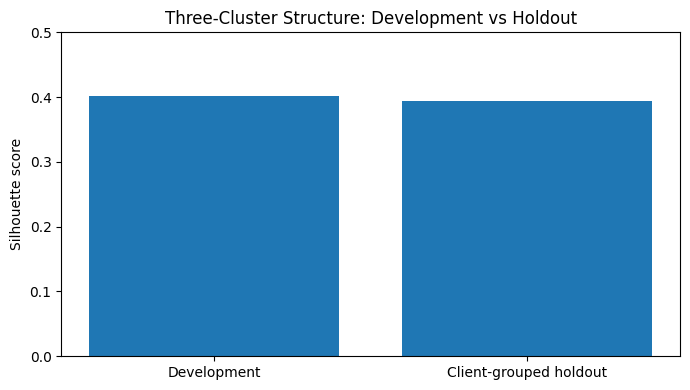

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))

plt.bar(
    validation_results["evaluation"],
    validation_results["silhouette"]
)

plt.ylabel("Silhouette score")
plt.title("Three-Cluster Structure: Development vs Holdout")
plt.ylim(0, 0.5)
plt.tight_layout()

plt.show()

In [ ]:
# Recreate the validated K=3 development cluster profiles
# for the capstone results section.

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans

cluster_features = [
    "impressions",
    "clicks",
    "ctr",
    "avg_position",
    "position_volatility"
]

X_model = feature_vector[cluster_features].copy()

X_model["impressions"] = np.log1p(
    X_model["impressions"]
)

X_model["clicks"] = np.log1p(
    X_model["clicks"]
)

preprocessor = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

X_scaled = preprocessor.fit_transform(X_model)

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

feature_vector["cluster"] = kmeans.fit_predict(X_scaled)

cluster_profiles = (
    feature_vector
    .groupby("cluster")
    .agg(
        pages=("cluster", "size"),
        median_impressions=("impressions", "median"),
        median_clicks=("clicks", "median"),
        median_ctr=("ctr", "median"),
        median_avg_position=("avg_position", "median"),
        median_position_volatility=(
            "position_volatility",
            "median"
        )
    )
    .reset_index()
)

cluster_profiles["share_pct"] = (
    100
    * cluster_profiles["pages"]
    / len(feature_vector)
)

display(cluster_profiles)

,cluster,pages,median_impressions,median_clicks,median_ctr,median_avg_position,median_position_volatility,share_pct
0,0,47913,2592.0,6.0,0.280112,6.396975,2.640917,27.109620
1,1,36510,62.0,0.0,0.000000,41.375000,22.430576,20.657697
2,2,92315,58.0,0.0,0.000000,7.692295,4.780433,52.232683


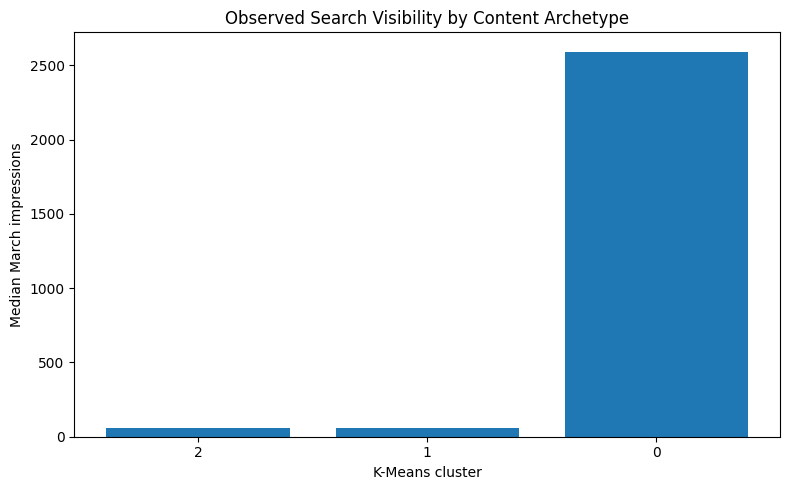

In [ ]:
# Visual comparison of the three observed archetypes

profile_plot = cluster_profiles.sort_values(
    "median_impressions"
)

plt.figure(figsize=(8, 5))

plt.bar(
    profile_plot["cluster"].astype(str),
    profile_plot["median_impressions"]
)

plt.xlabel("K-Means cluster")
plt.ylabel("Median March impressions")
plt.title("Observed Search Visibility by Content Archetype")
plt.tight_layout()

plt.show()

### Interpretation

The clustering separates the March 2026 content inventory into three measurable performance patterns rather than semantic content categories.

One group is characterized by low visibility and higher position volatility. A second group has substantially greater observed search visibility alongside stronger median CTR, ranking position, and lower volatility. The third group combines relatively strong observed average position with low visibility.

The baseline identifies **1,368 client-content pairs** with a positive CTR-opportunity score under the stated 500-impression threshold. This represents approximately **0.77%** of the March feature vectors.

The client-grouped holdout silhouette (**0.3933**) is close to the development silhouette (**0.4017**), while the holdout ARI is **0.7306**. These results indicate that the three-cluster structure remains reasonably similar for unseen clients under the selected validation design.

However, these measurements do not establish that any cluster causes better or worse future performance. They only describe patterns observed in the March 2026 feature space.

### What this work cannot claim

This analysis is a descriptive and decision-support study. Several limitations define how its results should be interpreted.

#### 1. The clusters are not ground-truth labels

K-Means creates groups from the selected feature space. The three archetypes are therefore descriptive patterns, not verified content categories, quality labels, or business classifications.

#### 2. The analysis does not establish causality

The observed relationships between impressions, clicks, CTR, position, and volatility do not establish that one metric causes another or that changing a page will produce a specific search-performance outcome.

#### 3. Search intent is not directly observed

The feature vector contains aggregate search-performance measurements but does not contain the underlying search queries or their semantic intent. A low CTR therefore cannot automatically be attributed to a title, meta description, content quality, or intent mismatch.

#### 4. SERP and technical context are missing

The clustering features do not directly capture SERP features, competitors, indexing conditions, canonicalization, redirects, page availability, or other technical factors that can affect observed search performance.

#### 5. Business value is not represented

The model does not know which pages are strategically important, commercially valuable, legally sensitive, or important to users. A high review priority therefore does not imply high business priority.

#### 6. Historical and temporal effects are simplified

The main feature vector uses a fixed March 2026 development window. Seasonality, publication cohorts, refresh history, and longer-term changes may influence observed performance but are not fully represented in the clustering model.

#### 7. Uneven GSC availability affects coverage

Only observations with available GSC data contribute to the search-performance feature vector. The results therefore describe the measurable GSC-covered portion of the inventory rather than every content item in the warehouse.

#### 8. K-Means imposes a fixed structure

K-Means assigns every included page to one of the selected clusters. Real content-performance patterns may be continuous or overlapping rather than naturally separated into three groups.

#### 9. Validation does not prove future performance

The client-grouped holdout checks whether the observed clustering structure remains similar for unseen clients. It does not prove that the clusters will remain stable across future months or predict future traffic, rankings, or conversions.

#### 10. The action queue requires human review

The ranked queue is a prioritization artifact. It should not automatically trigger rewriting, pruning, merging, canonical changes, or other content or technical actions.

### Honest interpretation

The strongest supported conclusion is that the analysis provides a reproducible way to organize observed March 2026 search-performance patterns into three descriptive archetypes and combine those patterns with a transparent CTR-opportunity baseline for human review.

The analysis should therefore be used as **decision support**, not as an automated content strategy or a prediction of search-engine behaviour.

In [ ]:
limitations_check = {
    "supervised_label": False,
    "causal_claim_supported": False,
    "search_intent_observed": False,
    "business_value_observed": False,
    "future_performance_prediction": False,
    "human_review_required": True,
    "decision_support_only": True
}

display(
    pd.DataFrame(
        [
            {"check": key, "value": value}
            for key, value in limitations_check.items()
        ]
    )
)

,check,value
0,supervised_label,False
1,causal_claim_supported,False
2,search_intent_observed,False
3,business_value_observed,False
4,future_performance_prediction,False
5,human_review_required,True
6,decision_support_only,True


### Action playbook

The recommendation system uses the transparent baseline score as the primary ranking signal and the K-Means archetype as contextual information.

The resulting queue contains **1,368 client-content pairs** with a positive baseline opportunity score. These candidates have at least 500 observed March impressions and an observed CTR below the median CTR for their average-position tier.

The ranking should be interpreted as **review priority**, not as a recommendation to immediately change the page.

### Priority 1 — High-visibility CTR review

**Signal:** High observed impressions combined with a positive CTR gap.

**Reason code:** `high_visibility_low_ctr`

**Recommended review:** Inspect search intent, SERP presentation, title/meta alignment, competing results, and page relevance before deciding whether a CTR-focused change is appropriate.

**Relative value:** Potentially high review value because the page already has measurable search visibility.

**Human gate:** No title, meta, or content change should be made automatically.

### Priority 2 — Low-visibility, relatively well-ranked pages

These pages have relatively strong observed average position but low search visibility.

**Recommended review:** Investigate search demand, query coverage, indexing, content relevance, and whether the observed position is based on sufficiently meaningful impressions.

A relatively good average position alone is not evidence that a page is a hidden opportunity.

### Priority 3 — Low-visibility, unstable pages

These pages combine low observed visibility with greater position volatility.

**Recommended review:** Investigate technical status, search demand, historical changes, content relevance, and whether the page has enough data to support a reliable action.

Low volume should not automatically result in rewriting, pruning, or merging.

### Archetype-to-action mapping

| Observed archetype | Review focus | Possible human action |
|---|---|---|
| Low-visibility, unstable pages | Visibility, technical status, content quality, historical changes | Investigate before deciding |
| High-visibility performance pages | CTR, SERP context, search intent, performance protection | Review CTR opportunity or protect current performance |
| Low-visibility, relatively well-ranked pages | Search demand, query coverage, indexing, relevance | Investigate visibility opportunity |

These mappings are investigation priorities rather than automated actions.

### Human-review rule

Every ranked candidate must be reviewed using evidence that is not contained in the clustering features, including search intent, SERP context, technical status, business value, freshness, and possible cannibalization.

### What should not be automated

This analysis should not automatically:

- Rewrite titles or meta descriptions.
- Rewrite or generate page content.
- Delete or prune pages.
- Merge pages.
- Change canonical URLs or redirects.
- Classify a page as low quality.
- Infer search intent or business value.
- Claim that an action will improve rankings or traffic.

The final decision remains with a human reviewer.

In [ ]:
# Build the paper's ranked recommendation queue

ranked_recommendations = (
    results_df[
        results_df["baseline_score"] > 0
    ]
    .copy()
    .sort_values(
        "baseline_score",
        ascending=False
    )
    .reset_index(drop=True)
)

ranked_recommendations["rank"] = (
    np.arange(len(ranked_recommendations)) + 1
)

ranked_recommendations["reason_code"] = (
    "high_visibility_low_ctr"
)

ranked_recommendations = ranked_recommendations[
    [
        "rank",
        "client_hash_id",
        "content_hash_id",
        "baseline_score",
        "reason_code",
        "impressions",
        "clicks",
        "ctr",
        "avg_position",
        "position_volatility"
    ]
]

print(
    "Ranked recommendation candidates:",
    len(ranked_recommendations)
)

display(
    ranked_recommendations.head(20)
)

Ranked recommendation candidates: 1368


,rank,client_hash_id,content_hash_id,baseline_score,reason_code,impressions,clicks,ctr,avg_position,position_volatility
0,1,client_1a730cb2640a1abf,content_d61fc394d10cba41,0.987203,high_visibility_low_ctr,38000.0,1.0,0.002632,2.740744,2.044146
1,2,client_fef1a8f436438636,content_66bf45eb0c5bb550,0.930140,high_visibility_low_ctr,24259.0,1.0,0.004122,2.784944,1.506762
2,3,client_a80fca3f171ed1de,content_fa17add7836d36c3,0.908622,high_visibility_low_ctr,12588.0,0.0,0.000000,1.902457,1.579138
3,4,client_73cda7b4e4f265ea,content_d397987113cb84a0,0.885378,high_visibility_low_ctr,9887.0,0.0,0.000000,1.953104,0.441814
4,5,client_23a62021009f63c4,content_a27b382f00aa75c6,0.861768,high_visibility_low_ctr,7736.0,0.0,0.000000,2.259812,2.027308
5,6,client_73cda7b4e4f265ea,content_b9acd1ebff7d34ff,0.860672,high_visibility_low_ctr,25941.0,3.0,0.011565,2.418270,0.900653
6,7,client_e547b89c05043229,content_83167156f76e33e5,0.849739,high_visibility_low_ctr,6827.0,0.0,0.000000,1.136714,0.651147
7,8,client_fef1a8f436438636,content_1bc8782404e3b132,0.833918,high_visibility_low_ctr,5792.0,0.0,0.000000,2.339752,1.622473
8,9,client_20259bd6705d81d4,content_9cec93fc44a7ab41,0.814670,high_visibility_low_ctr,4742.0,0.0,0.000000,1.852298,1.593465
9,10,client_20259bd6705d81d4,content_35ddcd760c64da18,0.812444,high_visibility_low_ctr,11090.0,1.0,0.009017,0.989128,1.579008


In [ ]:
# Create simple review-priority tiers from the ranked queue.
# These tiers describe review order, not business value.

ranked_recommendations["priority_tier"] = pd.cut(
    ranked_recommendations["rank"],
    bins=[
        0,
        min(100, len(ranked_recommendations)),
        min(500, len(ranked_recommendations)),
        len(ranked_recommendations)
    ],
    labels=["Top review queue", "Secondary review queue", "Extended review queue"],
    include_lowest=True
)

priority_summary = (
    ranked_recommendations["priority_tier"]
    .value_counts()
    .sort_index()
    .rename_axis("priority_tier")
    .reset_index(name="candidates")
)

display(priority_summary)

,priority_tier,candidates
0,Top review queue,100
1,Secondary review queue,400
2,Extended review queue,868


### Recommendation takeaway

The analysis supports a simple operational workflow:

**Rank → Investigate → Validate → Act**

1. **Rank** pages using the transparent CTR-opportunity baseline.
2. **Investigate** the relevant archetype and supporting search-performance evidence.
3. **Validate** search intent, SERP context, technical status, business value, and historical context.
4. **Act** only when the human review provides sufficient evidence for a specific change.

This workflow converts the model output into practical decision support while preserving a human decision boundary.

### Paper artifacts

The deployed research page will embed a small set of figures and tables that directly support the research narrative.

The selected artifacts are:

1. **Validation comparison** — development versus client-grouped holdout silhouette for K=3.
2. **Cluster profile comparison** — observed median search-performance characteristics across the three archetypes.
3. **Baseline opportunity distribution** — distribution of the transparent review-priority score.
4. **Results table** — compact summary of the validated model and baseline findings.
5. **Recommendation summary** — ranked review queue size and archetype context.

The figures are descriptive and are intended to make the measured results easier to inspect. They are not presented as evidence of causality or future performance.

Row-level client and content identifiers are not included in public figures or tables.

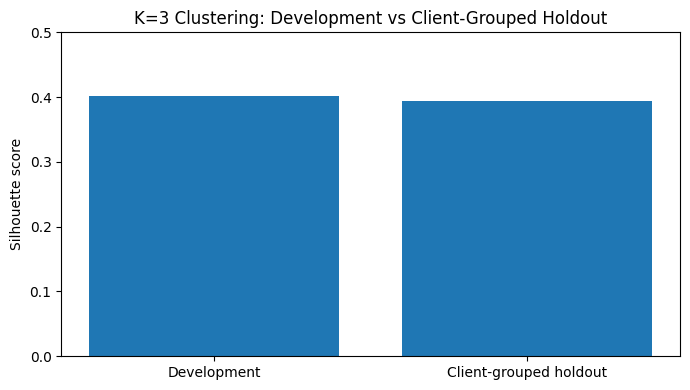

Saved: work/figures/capstone_validation_comparison.png


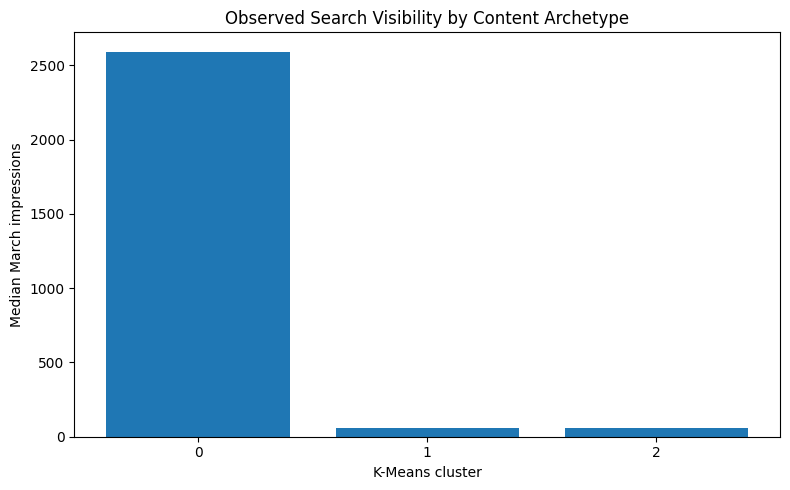

Saved: work/figures/capstone_cluster_visibility.png


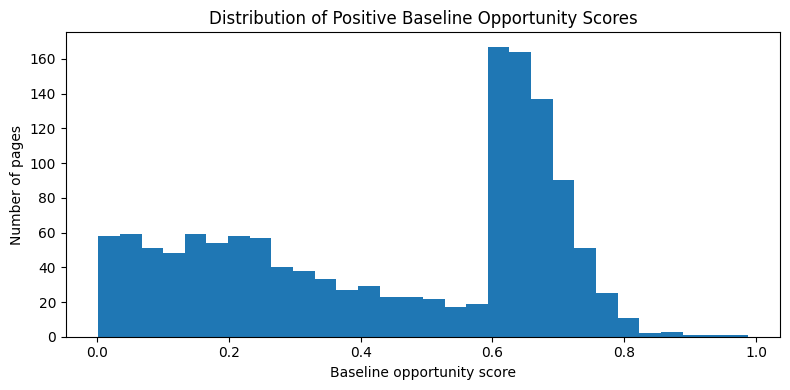

Saved: work/figures/capstone_baseline_distribution.png


In [ ]:
import os
import matplotlib.pyplot as plt

os.makedirs("work/figures", exist_ok=True)

# --------------------------------------------------
# Figure 1: Validation comparison
# --------------------------------------------------

plt.figure(figsize=(7, 4))

plt.bar(
    validation_results["evaluation"],
    validation_results["silhouette"]
)

plt.ylabel("Silhouette score")
plt.title("K=3 Clustering: Development vs Client-Grouped Holdout")
plt.ylim(0, 0.5)
plt.tight_layout()

validation_path = (
    "work/figures/capstone_validation_comparison.png"
)

plt.savefig(
    validation_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved:", validation_path)


# --------------------------------------------------
# Figure 2: Cluster profile comparison
# --------------------------------------------------

profile_plot = cluster_profiles.copy()

plt.figure(figsize=(8, 5))

plt.bar(
    profile_plot["cluster"].astype(str),
    profile_plot["median_impressions"]
)

plt.xlabel("K-Means cluster")
plt.ylabel("Median March impressions")
plt.title("Observed Search Visibility by Content Archetype")
plt.tight_layout()

cluster_path = (
    "work/figures/capstone_cluster_visibility.png"
)

plt.savefig(
    cluster_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved:", cluster_path)


# --------------------------------------------------
# Figure 3: Baseline opportunity distribution
# --------------------------------------------------

plt.figure(figsize=(8, 4))

positive_scores = results_df.loc[
    results_df["baseline_score"] > 0,
    "baseline_score"
]

plt.hist(
    positive_scores,
    bins=30
)

plt.xlabel("Baseline opportunity score")
plt.ylabel("Number of pages")
plt.title("Distribution of Positive Baseline Opportunity Scores")
plt.tight_layout()

baseline_path = (
    "work/figures/capstone_baseline_distribution.png"
)

plt.savefig(
    baseline_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved:", baseline_path)

In [ ]:
results_table = pd.DataFrame({
    "Metric": [
        "March client-content vectors",
        "Baseline opportunity candidates",
        "Baseline opportunity rate",
        "K=3 development silhouette",
        "K=3 holdout silhouette",
        "Holdout ARI"
    ],
    "Value": [
        len(feature_vector),
        baseline_opportunity_count,
        f"{baseline_opportunity_rate * 100:.3f}%",
        "0.4017",
        "0.3933",
        "0.7306"
    ]
})

display(results_table)

,Metric,Value
0,March client-content vectors,176738
1,Baseline opportunity candidates,1368
2,Baseline opportunity rate,0.774%
3,K=3 development silhouette,0.4017
4,K=3 holdout silhouette,0.3933
5,Holdout ARI,0.7306


In [ ]:
archetype_table = cluster_profiles.copy()

archetype_table = archetype_table[
    [
        "cluster",
        "pages",
        "share_pct",
        "median_impressions",
        "median_clicks",
        "median_ctr",
        "median_avg_position",
        "median_position_volatility"
    ]
].copy()

archetype_table["share_pct"] = (
    archetype_table["share_pct"].round(2)
)

archetype_table["median_impressions"] = (
    archetype_table["median_impressions"].round(2)
)

archetype_table["median_clicks"] = (
    archetype_table["median_clicks"].round(2)
)

archetype_table["median_ctr"] = (
    archetype_table["median_ctr"].round(4)
)

archetype_table["median_avg_position"] = (
    archetype_table["median_avg_position"].round(2)
)

archetype_table["median_position_volatility"] = (
    archetype_table["median_position_volatility"].round(2)
)

display(archetype_table)

,cluster,pages,share_pct,median_impressions,median_clicks,median_ctr,median_avg_position,median_position_volatility
0,0,47913,27.11,2592.0,6.0,0.2801,6.40,2.64
1,1,36510,20.66,62.0,0.0,0.0000,41.38,22.43
2,2,92315,52.23,58.0,0.0,0.0000,7.69,4.78


In [ ]:
recommendation_summary = pd.DataFrame({
    "Metric": [
        "Ranked review candidates",
        "Reason code",
        "Ranking signal",
        "Human review required",
        "Automatic content changes"
    ],
    "Value": [
        len(ranked_recommendations),
        "high_visibility_low_ctr",
        "Transparent CTR opportunity score",
        "Yes",
        "No"
    ]
})

display(recommendation_summary)

,Metric,Value
0,Ranked review candidates,1368
1,Reason code,high_visibility_low_ctr
2,Ranking signal,Transparent CTR opportunity score
3,Human review required,Yes
4,Automatic content changes,No


### Capstone final self-check

- [x] Research question and decision supported are clearly stated.
- [x] Abstract appears at the top and follows question → method → result.
- [x] Dataset, warehouse scope, date windows, and exclusions are documented.
- [x] March 2026 is the fixed development window.
- [x] Final feature vector contains five search-performance features.
- [x] Baseline is defined transparently.
- [x] K-Means methodology and K=3 selection are documented.
- [x] Client-grouped validation is documented.
- [x] Leakage checks are documented and identifier leakage is false.
- [x] Results include baseline and validated clustering metrics.
- [x] Limitations and honest claim language are explicit.
- [x] Ranked recommendations use the ML-10 action playbook.
- [x] Human review and no-go cases are documented.
- [x] Public artifacts contain aggregate results rather than client names, URLs, or private queries.
- [x] Figures and result tables were generated for the deployed paper.
- [x] The notebook is intended to mirror the deployed research paper.

# ML-12 — Closing communication artifacts

## 5-minute demo outline

### 1. Problem — 45 seconds
What performance archetypes exist across a large content inventory, and how can those patterns support content-review prioritization?

### 2. Data — 45 seconds
The analysis uses the FlyRank internship warehouse, containing 78.8M daily observations across January 2025 to June 2026. March 2026 was used as the fixed development window, producing 176,738 client-content feature vectors with five GSC performance features.

### 3. Method — 60 seconds
A transparent CTR-opportunity baseline was combined with K-Means clustering. The analysis used log transformation, imputation, standardization, client-grouped validation, and explicit leakage checks.

### 4. Results — 75 seconds
The three-cluster structure produced a development silhouette of 0.4017 and client-grouped holdout silhouette of 0.3933, with a holdout ARI of 0.7306. The baseline identified 1,368 positive review opportunities.

### 5. Action playbook — 45 seconds
The baseline ranks review opportunities, while the archetypes provide context. The workflow is Rank → Investigate → Validate → Act.

### 6. Honest boundary — 30 seconds
The system does not predict future rankings or establish causality. It does not automatically rewrite, prune, merge, or change technical page settings. Human review remains required.

---

## Social-post cut

Built a research workflow for discovering structured content-performance archetypes from large-scale search data.

Using the FlyRank ML Internship warehouse, I aggregated March 2026 Google Search Console measurements into 176,738 client-content feature vectors and compared a transparent CTR-opportunity baseline with K-Means clustering.

The final analysis produced three descriptive performance archetypes and a ranked review queue of 1,368 candidates.

The key lesson: ML output is not the final decision. The useful part is turning measured patterns into explainable, human-reviewed actions while being explicit about what the data cannot establish.

---

## Employer-facing summary

I built an end-to-end machine-learning research workflow on the FlyRank internship warehouse, covering data contracts, feature engineering, leakage auditing, baseline scoring, unsupervised clustering, grouped validation, and an action playbook. The final system used K-Means to identify three descriptive search-performance archetypes and combined them with a transparent CTR-opportunity baseline to prioritize 1,368 pages for human review. I focused on reproducibility and honest evaluation, including client-grouped validation, explicit leakage checks, public-safe artifacts, and clear boundaries around what the model should not automate.

In [ ]:
ml12_artifacts = {
    "demo_outline": True,
    "social_post": True,
    "employer_summary": True,
    "paper_sections_completed": 7,
    "abstract_included": True,
    "human_review_required": True,
    "automatic_content_changes": False
}

display(
    pd.DataFrame(
        [
            {"artifact": key, "completed": value}
            for key, value in ml12_artifacts.items()
        ]
    )
)

,artifact,completed
0,demo_outline,True
1,social_post,True
2,employer_summary,True
3,paper_sections_completed,7
4,abstract_included,True
5,human_review_required,True
6,automatic_content_changes,False


## 8. Five-Minute Demo Outline

### 1. Question — 45 seconds
What performance archetypes exist across the content inventory, and how can those observed patterns support content-review prioritization?

### 2. Method — 60 seconds
Explain the March 2026 feature set:
- impressions
- clicks
- CTR
- average position
- position volatility

Describe the transparent CTR-opportunity baseline and K-Means clustering approach.

### 3. One Chart — 60 seconds
Show the key clustering/result visualization and briefly explain what distinguishes the observed performance archetypes.

### 4. Honest Result — 60 seconds
The analysis identified three descriptive performance clusters and 1,368 pages with positive baseline opportunity scores.

The client-grouped holdout silhouette was 0.3933 compared with a development silhouette of 0.4017, while the holdout ARI was 0.7306.

These results support the stability of the observed structure under the selected validation design, but they do not establish causality or predict future search performance.

### 5. Recommendation — 45 seconds
Use the transparent CTR-opportunity score to create a review queue.

Rank → Investigate → Validate → Act.

Human review remains required before making content changes.

### Closing
The system is intended as decision support for content teams, not as an automated content-rewriting or future-performance prediction system.

## Shareable Cuts

### Social Post

I built a data-driven content-performance analysis during my FlyRank AI Internship, using March 2026 Google Search Console measurements across a large content inventory.

Instead of treating individual pages in isolation, I used measurable performance features such as impressions, clicks, CTR, average position, and position volatility to identify descriptive performance archetypes and create a transparent CTR-opportunity review queue.

The analysis produced three descriptive clusters and identified 1,368 pages with positive baseline opportunity scores. The resulting workflow is designed for human-guided content review rather than automated rewriting or future-performance prediction.


### Employer-Facing Summary

Built a data-driven content-performance analysis using March 2026 Google Search Console data from the FlyRank internship warehouse. I engineered page-level performance features, compared a transparent CTR-opportunity baseline with K-Means clustering, and validated the cluster structure using a client-grouped holdout. The analysis identified three descriptive performance clusters and a review queue of 1,368 pages, producing a human-in-the-loop workflow for prioritizing content investigation.

### Social Post

I explored structured content-performance archetypes using March 2026 Google Search Console data from the FlyRank internship warehouse. I engineered page-level performance features, compared a transparent CTR-opportunity baseline with K-Means clustering, and validated the observed structure using a client-grouped holdout. The analysis identified three descriptive performance clusters and a 1,368-page review queue, with the final workflow designed to support human content investigation rather than automate content changes.